In [ ]:
from mymodels import mobilenet_v3_small, train, test_error, kCV
from dataUtils import *
from sklearn.model_selection import KFold
from torch.utils.data import Subset
from torch import nn,optim,save,load
import matplotlib.pyplot as plt
import time
from torch.cuda import synchronize

device = 'cuda'

In [2]:
model = mobilenet_v3_small(dropout=0.3088235294117647)
model.to(device)
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.00025266266504172765)
epochs = 15
dataset = make_train_val_set()
all_loss = kCV(5,dataset,model,loss_fn,optimizer,epochs=epochs,batch_size=32)
save(model.state_dict(), 'models/mobile_net.pth')

FOLD 0
EPOCH 1
	train loss:	 0.036535933119606
	val. loss:	 0.05244853764772415
EPOCH 2
	train loss:	 0.02379215292024369
	val. loss:	 0.048463708981871606
EPOCH 3
	train loss:	 0.02027096521413448
	val. loss:	 0.04914544887840748
EPOCH 4
	train loss:	 0.01892568406230789
	val. loss:	 0.04520586557686329
EPOCH 5
	train loss:	 0.015715669526965643
	val. loss:	 0.046106207072734835
EPOCH 6
	train loss:	 0.015672112924369926
	val. loss:	 0.04762951374053955
EPOCH 7
	train loss:	 0.013797776158233839
	val. loss:	 0.03498775079846382
EPOCH 8
	train loss:	 0.014028341618689651
	val. loss:	 0.01530634006485343
EPOCH 9
	train loss:	 0.013546373989737156
	val. loss:	 0.017918177265673876
EPOCH 10
	train loss:	 0.013181483852962146
	val. loss:	 0.014535828176885843
EPOCH 11
	train loss:	 0.012509885866537082
	val. loss:	 0.016459861658513545
EPOCH 12
	train loss:	 0.01197456942909226
	val. loss:	 0.01300855891779065
EPOCH 13
	train loss:	 0.011298271520918578
	val. loss:	 0.014352693893015385
EP

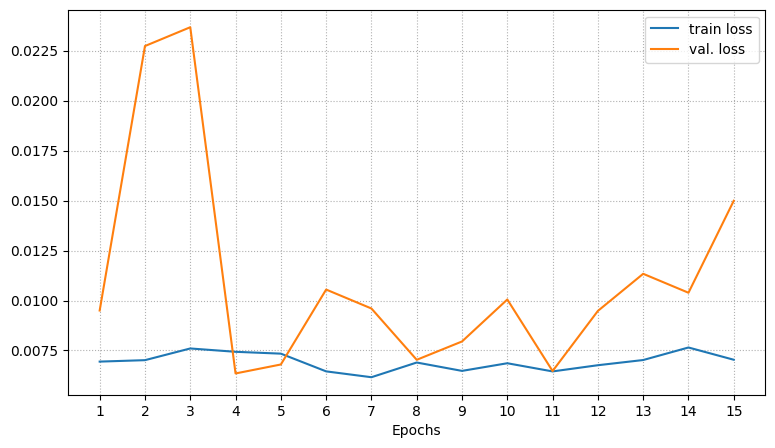

In [27]:
to_json('results/mobilenet.json',all_loss)
net = mobilenet_v3_small()
net.load_state_dict(load('models/mobile_net.pth',weights_only=True))
all_loss = load_json('results/mobilenet.json')
plt.subplots(figsize=(9,5))
epochs = len(all_loss['all-loss'][0]['train'])
plt.plot(range(1,epochs+1),all_loss['all-loss'][-1]['train'],label='train loss')
plt.plot(range(1,epochs+1),all_loss['all-loss'][-1]['validation'],label='val. loss')
plt.xticks(range(1,epochs+1))
plt.legend()
plt.xlabel('Epochs')
plt.grid(linestyle='dotted')
plt.savefig('mobilenet_loss.pdf',bbox_inches='tight', pad_inches=0)

In [18]:
cv = all_loss['CV-loss']
test = test_error(net,make_test_set())
validation = all_loss['all-loss'][-1]['validation'][-1]
train = all_loss['all-loss'][-1]['train'][-1]

print(f'train: {train}\nvalid.: {validation}\ntest: {test}\ncv: {cv}')

train: 0.007036601238389861
valid.: 0.014992445725947618
test: 0.014505480453920626
cv: 0.013625770768150686


In [23]:
testloader = DataLoader(
    make_test_set(), batch_size=4, shuffle=False, num_workers=2
)
net.eval()
total_time = 0
device = 'cuda'
net.to(device)
test_error(net,make_test_set(),device='cuda') #WARM UP
for data in testloader:
    x, area, ate, are = data
    x = x.to(device)
    area = area.to(device)
    ate = ate.to(device)
    are = are.to(device)
    synchronize()
    start_time = time.time()
    outputs = net(x,area)
    synchronize()
    end_time = time.time()
    total_time += (end_time-start_time)/len(data)
inf_time = total_time/len(testloader)
print(f'inference time GPU: {inf_time}')
total_time = 0
device = 'cpu'
net.to(device)
test_error(net,make_test_set(),device='cpu') #WARM UP
for data in testloader:
    x, area, ate, are = data
    x = x.to(device)
    area = area.to(device)
    ate = ate.to(device)
    are = are.to(device)
    synchronize()
    start_time = time.time()
    outputs = net(x,area)
    synchronize()
    end_time = time.time()
    total_time += (end_time-start_time)/len(data)
inf_time = total_time/len(testloader)
print(f'inference time CPU: {inf_time}')

inference time GPU: 0.0008319054526844244
inference time CPU: 0.003397240035835354


In [24]:
param_size = 0
for param in net.parameters():
    param_size += param.nelement() * param.element_size()
buffer_size = 0
for buffer in net.buffers():
    buffer_size += buffer.nelement() * buffer.element_size()

size_all_mb = (param_size + buffer_size) / 1024**2
print('model size: {:.3f}MB'.format(size_all_mb))

model size: 5.847MB
